# Random response generator

This sheet will generate random systems and show their step responses. See if you can predict the responses from the transfer functions and the poles and zeros.

This notebook assumes version 0.8.0 of the control library or better

In [1]:
import control
import numpy
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def viz(order):
    # Not all random transfer functions work, so we generate one
    # and try to calculate the step response, only continuing when it works
    valid = False
    while not valid:
        coeffs = (numpy.random.random(order)*3).tolist() + [1]
        G = control.tf(1, coeffs)

        try:
            t, y = control.step_response(G)
            valid = True
        except ValueError:
            continue

    fig, [ax_complex, ax_time] = plt.subplots(1, 2, figsize=(10, 5))
    
    plt.sca(ax_complex)
    control.pzmap(G)
    ax_complex.axis('equal')
    ax_complex.axis([-5, 5, -5, 5])
    ax_complex.grid()
    ax_time.plot(t, y)
    ax_time.axhline(1)

In [3]:
from ipywidgets import interact

interactive(children=(IntSlider(value=3, description='order', max=5, min=1), Output()), _dom_classes=('widget-…

<function __main__.viz(order)>

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


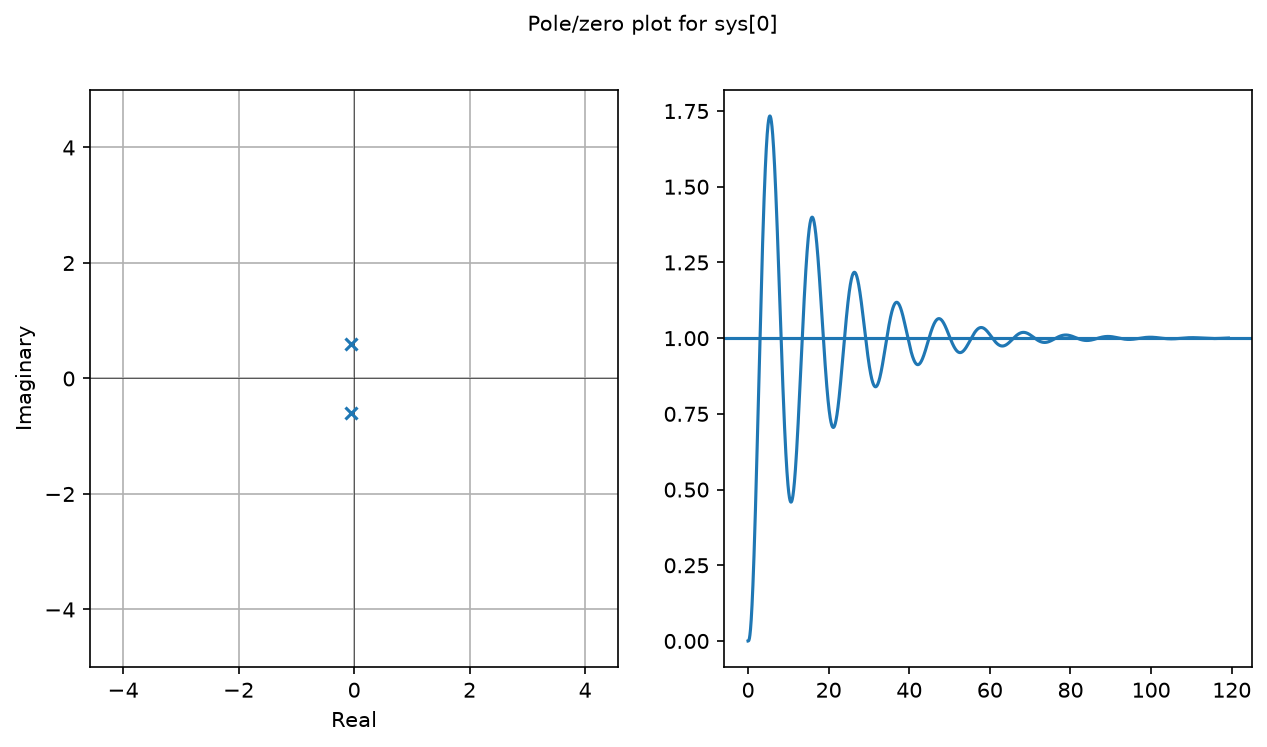

In [4]:
interact(viz, order=(1, 5))